# Phase 1 — Setup & Exploratory Data Analysis

**What this notebook does:**
- Configures AWS credentials and SageMaker session
- Creates and secures the S3 bucket with correct folder structure
- Uploads raw data to S3
- Performs EDA to understand class imbalance, nulls, and key features
- Sets billing alarm to protect your AWS budget

## 1. AWS & SageMaker session setup

In [7]:
import sagemaker
from sagemaker.core.helper.session_helper import Session
import boto3
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="../.env")

ROLE   = os.getenv("AWS_ROLE_ARN")
BUCKET = os.getenv("S3_BUCKET")
REGION = os.getenv("AWS_REGION", "us-east-1")
PREFIX = "credit-risk"

boto_session = boto3.Session(region_name = REGION)
sagemaker_session = Session(boto_session=boto_session)
s3 = boto_session.client("s3")

# Verify AWS connection
identity = boto_session.client("sts").get_caller_identity()
print(f"Account  : {identity['Account']}")
print(f"User ARN : {identity['Arn']}")
print(f"Region   : {REGION}")
print(f"Bucket   : {BUCKET}")
print(f"Role     : {ROLE}")

[05/28/26 18:05:12] INFO     Found credentials in shared credentials file: ~/.aws/credentials   credentials.py:1392

Account  : 064990711629
User ARN : arn:aws:iam::064990711629:user/Sagemaker
Region   : us-east-1
Bucket   : credit-risk-mlops-svp
Role     : arn:aws:iam::064990711629:user/Sagemaker


## Create & secure S3 bucket


In [8]:
def create_secure_bucket(s3_client, bucket_name:str, region:str):
    """Craete s3 bucket with versioning, encryption and public access blocked"""
    try:
        if region == "us-east-1":
            s3_client.create_bucket(Bucket=bucket_name)
        else:
            s3_client.create_bucket(
                Bucket= bucket_name,
                CreateBucketConfiguration={"LocationConstraint": region}
            )
        print(f"Bucket '{bucket_name}' created.")
    except s3_client.exceptions.BucketAlreadyOwnedByYou:
        print(f"Bucket '{bucket_name}' already exists — skipping creation.")

    # Block all public access
    s3_client.put_bucket_encryption(
        Bucket=bucket_name,
        ServerSideEncryptionConfiguration={
            "Rules": [{"ApplyServerSideEncryptionByDefault": {"SSEAlgorithm": "AES256"}}]
        }
    )
    print("AES-256 encryption enabled.")

create_secure_bucket(s3, BUCKET, REGION)

Bucket 'credit-risk-mlops-svp' created.
AES-256 encryption enabled.


In [ ]:
# Create folder structure
prefixes =[
    f"{PREFIX}/raw/",
    f"{PREFIX}/processed/train/",
    f"{PREFIX}/processed/test/",
    f"{PREFIX}/models/",
    f"{PREFIX}/clarify-output/",
    f"{PREFIX}/data-capture/",
    f"{PREFIX}/pipeline-output/",
    f"{PREFIX}/logs/"
]

for prefix in prefixes:
    s3.put_object(Bucket=BUCKET, Key=prefix)
    print(f"Created: s3://{BUCKET}/{prefix}")

print("\nS3 folder structure ready")

Created: s3://credit-risk-mlops-svp/credit-risk/raw/
Created: s3://credit-risk-mlops-svp/credit-risk/processed/train/
Created: s3://credit-risk-mlops-svp/credit-risk/processed/test/
Created: s3://credit-risk-mlops-svp/credit-risk/models/
Created: s3://credit-risk-mlops-svp/credit-risk/clarify-output/
Created: s3://credit-risk-mlops-svp/credit-risk/monitor-output/
Created: s3://credit-risk-mlops-svp/credit-risk/pipeline-output/
Created: s3://credit-risk-mlops-svp/credit-risk/logs/

S3 folder structure ready


## Exploratory Data Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("../data/application_train.csv")
print(f"shape        : {df.shape}")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head(3)

shape        : (307511, 122)
Memory usage : 536.7 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


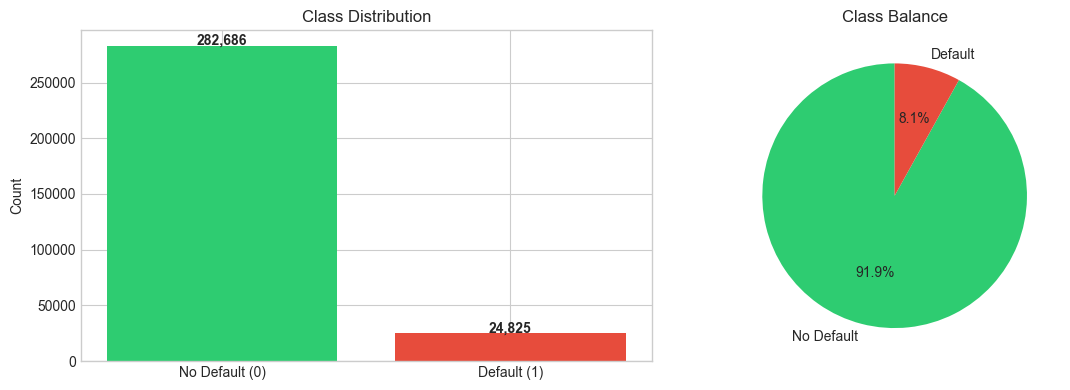


Class 0 (no default) : 282,686 (91.9%)
Class 1 (default)    : 24,825 (8.1%)

Recommended scale_pos_weight for XGBoost: 11.4


In [ ]:
# Checking Class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12,4))

counts = df["TARGET"].value_counts()
axes[0].bar(["No Default (0)", "Default (1)"], counts.values, color =["#2ecc71", "#e74c3c"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v +1000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts.values, labels= ["No Default", "Default"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90)
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

scale_pos_weight = counts[0] / counts[1]
print(f"\nClass 0 (no default) : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (default)    : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"\nRecommended scale_pos_weight for XGBoost: {scale_pos_weight:.1f}")

Columns with any nulls : 67 / 122
Columns >40% null      : 49 → will be dropped
Columns >20% null      : 50


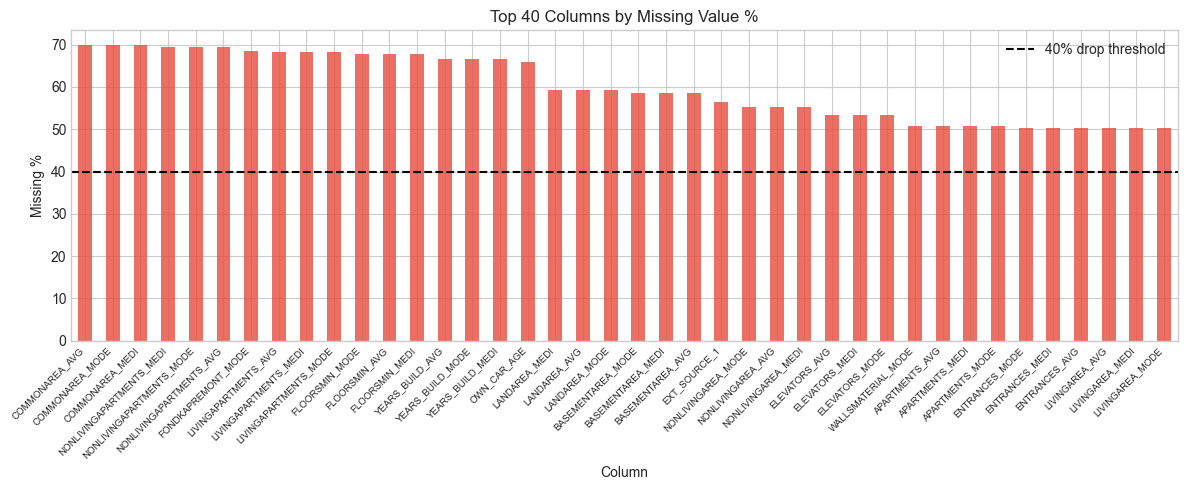

In [ ]:
# --- Missing value analysis ---
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]

print(f"Columns with any nulls : {len(null_pct_nonzero)} / {df.shape[1]}")
print(f"Columns >40% null      : {(null_pct > 40).sum()} → will be dropped")
print(f"Columns >20% null      : {(null_pct > 20).sum()}")

plt.figure(figsize=(12, 5))
null_pct_nonzero.head(40).plot(kind="bar", color="#e74c3c", alpha=0.8)
plt.axhline(y=40, color="black", linestyle="--", label="40% drop threshold")
plt.title("Top 40 Columns by Missing Value %")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig("../images/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

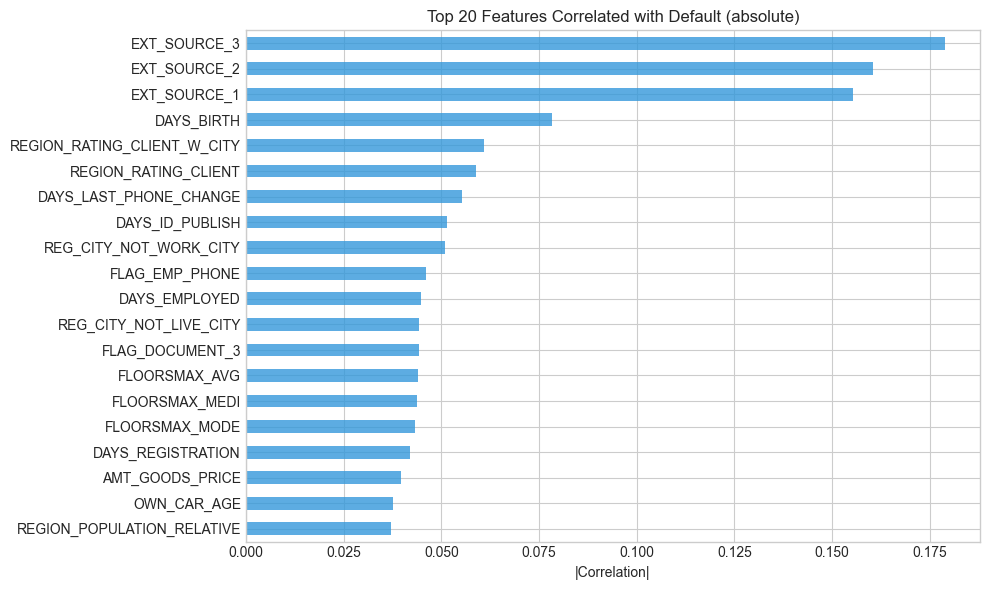

EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
FLOORSMAX_MODE                 0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE                0.039645
OWN_CAR_AGE                    0.037612
REGION_POPULATION_RELATIVE     0.037227


In [ ]:
# --- Top correlated numeric features with TARGET ---
numeric_df = df.select_dtypes(include="number")
correlations = numeric_df.corr()["TARGET"].abs().sort_values(ascending=False)
top_corr = correlations[1:21]   # exclude TARGET itself

plt.figure(figsize=(10, 6))
top_corr.plot(kind="barh", color="#3498db", alpha=0.8)
plt.title("Top 20 Features Correlated with Default (absolute)")
plt.xlabel("|Correlation|")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print(top_corr.to_string())

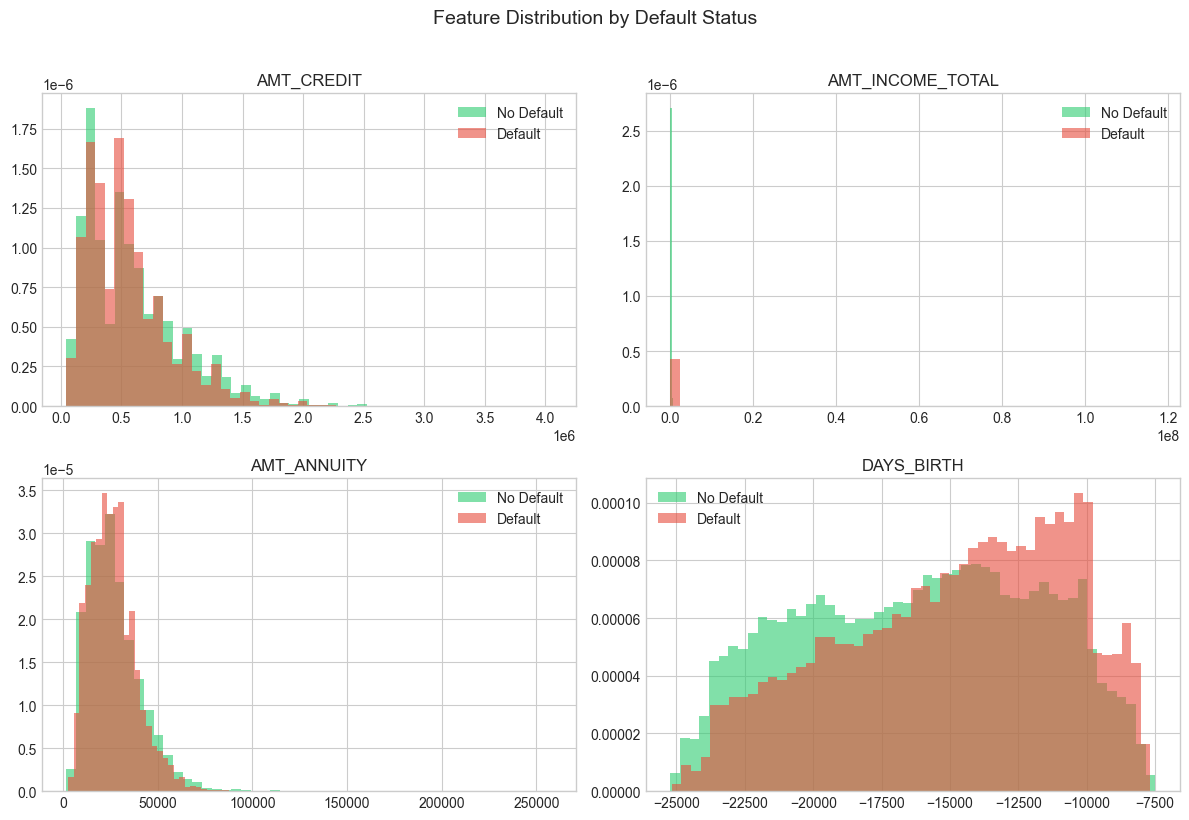

In [ ]:
# --- Key financial features distribution ---
key_features = ["AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "DAYS_BIRTH"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for target_val, color, label in [(0, "#2ecc71", "No Default"), (1, "#e74c3c", "Default")]:
        axes[i].hist(
            df[df["TARGET"] == target_val][feat].dropna(),
            bins=50, alpha=0.6, color=color, label=label, density=True
        )
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Feature Distribution by Default Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../images/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Upload raw data to S3

In [17]:
import time

local_file = "../data/application_train.csv"
s3_key = f"{PREFIX}/raw/application_train.csv"

print(f"uploading {local_file}  → s3://{BUCKET}/{s3_key}")
start = time.time()

s3.upload_file(
    Filename = local_file,
    Bucket = BUCKET,
    Key = s3_key,
    ExtraArgs = {
        "Tagging": "project=credit-risk&version=v1&source=kaggle",
        "ServerSideEncryption": "AES256"
    }
)

elapsed = time.time() - start
obj = s3.head_object(Bucket=BUCKET, Key=s3_key)
size_mb = obj["ContentLength"] / (1021 * 1024)

print(f"Upload complete in {elapsed:.1f}s")
print(f"S3 URI : s3://{BUCKET}/{s3_key}")
print(f"Size   : {size_mb:.1f} MB")
print(f"ETag   : {obj['ETag']}")

uploading ../data/application_train.csv  → s3://credit-risk-mlops-svp/credit-risk/raw/application_train.csv
Upload complete in 1043.2s
S3 URI : s3://credit-risk-mlops-svp/credit-risk/raw/application_train.csv
Size   : 158.9 MB
ETag   : "dd3bab7b8abb4c9a20fc5c708462297f-20"


In [18]:
# Validate data directly from s3
from io import StringIO

obj = s3.get_object(Bucket=BUCKET, Key=s3_key)
df_check = pd.read_csv(obj["Body"], nrows=5)

assert "TARGET" in df_check.columns, "ERROR: TARGET column missing!"
assert df_check.shape[1] == 122,     "ERROR: Unexpected column count!"

print("Data validation PASSED")
print(f"Columns : {df_check.shape[1]}")
print(f"\nSample:")
display(df_check[["SK_ID_CURR", "TARGET", "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY"]].head())


Data validation PASSED
Columns : 122

Sample:


,SK_ID_CURR,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY
0,100002,1,406597.5,202500.0,24700.5
1,100003,0,1293502.5,270000.0,35698.5
2,100004,0,135000.0,67500.0,6750.0
3,100006,0,312682.5,135000.0,29686.5
4,100007,0,513000.0,121500.0,21865.5


##  Save config for downstream notebooks

In [19]:
import json

config = {
    "ROLE": ROLE,
    "BUCKET": BUCKET,
    "REGION": REGION,
    "PREFIX": PREFIX,
    "RAW_S3_URI":   f"s3://{BUCKET}/{PREFIX}/raw/",
    "TRAIN_S3_URI": f"s3://{BUCKET}/{PREFIX}/processed/train/",
    "TEST_S3_URI":  f"s3://{BUCKET}/{PREFIX}/processed/test/",
    "SCALE_POS_WEIGHT":   round(scale_pos_weight, 1)
}

with open("../data/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config saved ")
print(json.dumps(config, indent=2))

Config saved 
{
  "ROLE": "arn:aws:iam::064990711629:user/Sagemaker",
  "BUCKET": "credit-risk-mlops-svp",
  "REGION": "us-east-1",
  "PREFIX": "credit-risk",
  "RAW_S3_URI": "s3://credit-risk-mlops-svp/credit-risk/raw/",
  "TRAIN_S3_URI": "s3://credit-risk-mlops-svp/credit-risk/processed/train/",
  "TEST_S3_URI": "s3://credit-risk-mlops-svp/credit-risk/processed/test/",
  "SCALE_POS_WEIGHT": 11.4
}
